In [1]:
!nvidia-smi -L || echo

import os, random, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from datetime import datetime

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BATCH_SIZE = 128
EPOCHS = 10
VAL_SPLIT = 0.1
PATIENCE = 3
LR = 1e-3

print(tf.__version__)
print("Seed:", SEED)


/bin/bash: line 1: nvidia-smi: command not found

2.19.0
Seed: 42


In [2]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = (x_train.astype("float32") / 255.0).reshape(-1, 784)
x_test  = (x_test.astype("float32")  / 255.0).reshape(-1, 784)

num_classes = 10

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape,  y_test.shape)

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1024, seed=SEED).batch(BATCH_SIZE)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 784) (60000,)
Test : (10000, 784) (10000,)


In [3]:
from tensorflow.keras import layers, models, optimizers, callbacks, losses, metrics

def get_optimizer(name: str, lr: float):
    name = name.lower()
    if name == "sgd":
        return optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)
    if name == "rmsprop":
        return optimizers.RMSprop(learning_rate=lr, rho=0.9)
    if name == "adam":
        return optimizers.Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)
    raise ValueError(f"Unknown optimizer: {name}")

def build_mlp(input_dim=784,
              hidden_units=(256, 128),
              activation="relu",
              dropout_rate=0.5,
              use_batchnorm=False,
              num_classes=10):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for i, h in enumerate(hidden_units):
        model.add(layers.Dense(h, kernel_initializer="he_normal"))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        if activation.lower() == "leakyrelu":
            model.add(layers.LeakyReLU(alpha=0.2))
        else:
            model.add(layers.Activation(activation))
        if dropout_rate and dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

def compile_and_train(model, optimizer_name="adam", lr=1e-3, epochs=10, verbose=0, val_split=0.1):
    opt = get_optimizer(optimizer_name, lr)
    model.compile(
        optimizer=opt,
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=[metrics.SparseCategoricalAccuracy(name="acc")]
    )
    cbs = [
        callbacks.ReduceLROnPlateau(monitor="val_acc", factor=0.5, patience=2, min_lr=1e-5, verbose=0),
        callbacks.EarlyStopping(monitor="val_acc", patience=PATIENCE, restore_best_weights=True, verbose=0),
    ]
    hist = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        validation_split=val_split,
        callbacks=cbs,
        verbose=verbose
    )
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    return hist, {"test_loss": float(test_loss), "test_acc": float(test_acc)}

def plot_histories(histories, title="Training Curves", metric="acc"):
    plt.figure(figsize=(6,4))
    for name, h in histories.items():
        plt.plot(h["val_"+metric], label=f"{name}")
    plt.title(f"{title} (val_{metric})")
    plt.xlabel("epoch")
    plt.ylabel(f"val_{metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

def bar_compare(scores_dict, title="Comparison (Test Acc)", ylabel="Test Acc"):
    names = list(scores_dict.keys())
    vals = [scores_dict[k] for k in names]
    plt.figure(figsize=(6,4))
    plt.bar(range(len(names)), vals)
    plt.xticks(range(len(names)), names, rotation=15)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis="y")
    for i, v in enumerate(vals):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom")
    plt.show()



[Activation] relu
→ Test Acc: 0.9806

[Activation] sigmoid
→ Test Acc: 0.9637

[Activation] tanh
→ Test Acc: 0.9632

[Activation] leakyrelu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


→ Test Acc: 0.9721


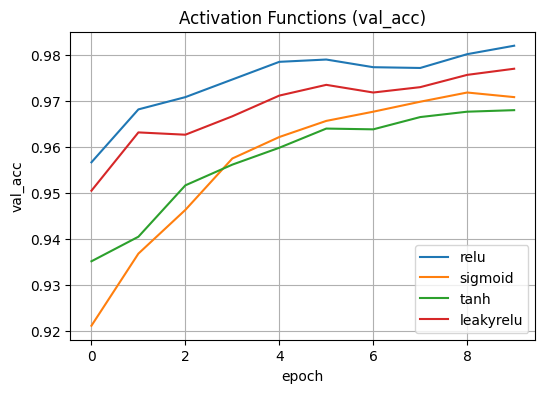

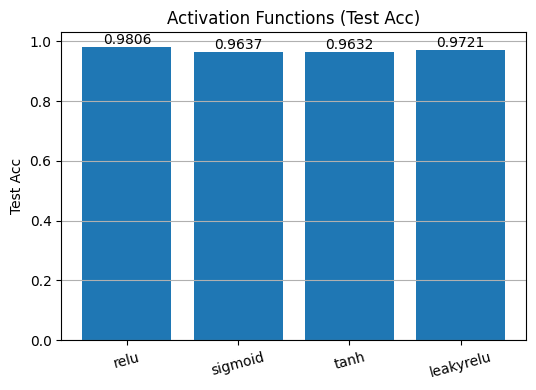

In [5]:
ACTIVATIONS = ["relu", "sigmoid", "tanh", "leakyrelu"]
act_histories = {}
act_scores = {}

for act in ACTIVATIONS:
    print(f"\n[Activation] {act}")
    model = build_mlp(
        hidden_units=(256, 128),
        activation=act,
        dropout_rate=0.5,
        use_batchnorm=False
    )
    hist, score = compile_and_train(
        model,
        optimizer_name="adam",
        lr=LR,
        epochs=EPOCHS,
        verbose=0,
        val_split=VAL_SPLIT
    )
    act_histories[act] = hist.history
    act_scores[act] = score["test_acc"]
    print(f"→ Test Acc: {score['test_acc']:.4f}")

plot_histories(act_histories, title="Activation Functions", metric="acc")
bar_compare(act_scores, title="Activation Functions (Test Acc)")



[Dropout] 0.0
→ Test Acc: 0.9820

[Dropout] 0.3
→ Test Acc: 0.9794

[Dropout] 0.5
→ Test Acc: 0.9770

[Dropout] 0.7
→ Test Acc: 0.9660


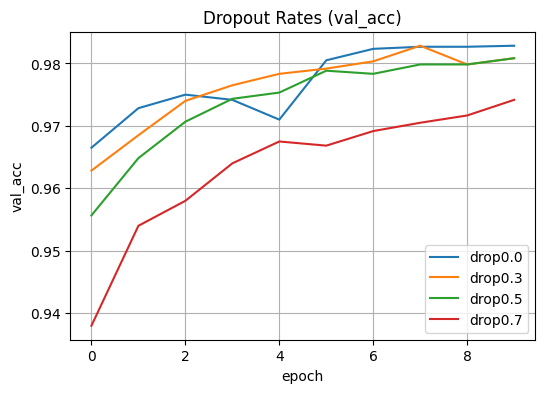

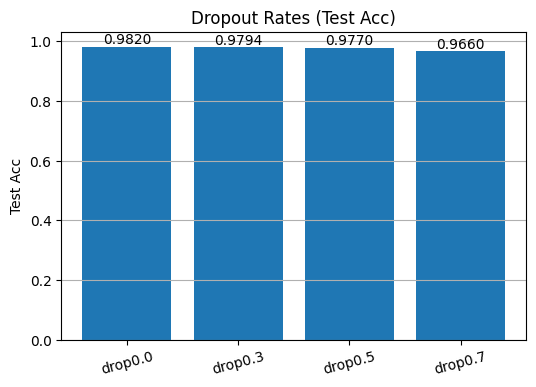

In [6]:
DROPOUTS = [0.0, 0.3, 0.5, 0.7]
drop_histories = {}
drop_scores = {}

for rate in DROPOUTS:
    name = f"drop{rate}"
    print(f"\n[Dropout] {rate}")
    model = build_mlp(
        hidden_units=(256, 128),
        activation="relu",
        dropout_rate=rate,
        use_batchnorm=False
    )
    hist, score = compile_and_train(
        model,
        optimizer_name="adam",
        lr=LR,
        epochs=EPOCHS,
        verbose=0,
        val_split=VAL_SPLIT
    )
    drop_histories[name] = hist.history
    drop_scores[name] = score["test_acc"]
    print(f"→ Test Acc: {score['test_acc']:.4f}")

plot_histories(drop_histories, title="Dropout Rates", metric="acc")
bar_compare(drop_scores, title="Dropout Rates (Test Acc)")



[Optimizer] sgd (lr=0.05)
→ Test Acc: 0.9769

[Optimizer] rmsprop (lr=0.001)
→ Test Acc: 0.9789

[Optimizer] adam (lr=0.001)
→ Test Acc: 0.9767


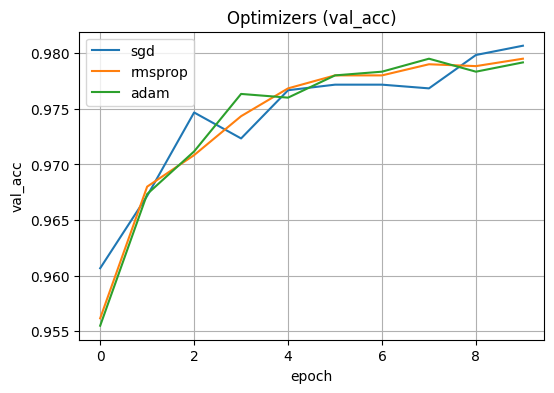

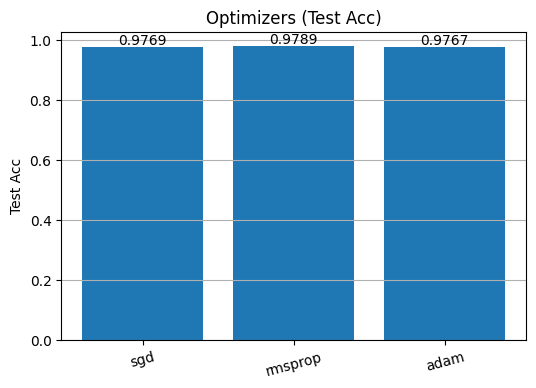

In [7]:
OPTIMS = {
    "sgd": 0.05,
    "rmsprop": 1e-3,
    "adam": 1e-3
}
opt_histories = {}
opt_scores = {}

for opt_name, lr in OPTIMS.items():
    print(f"\n[Optimizer] {opt_name} (lr={lr})")
    model = build_mlp(
        hidden_units=(256, 128),
        activation="relu",
        dropout_rate=0.5,
        use_batchnorm=False
    )
    hist, score = compile_and_train(
        model,
        optimizer_name=opt_name,
        lr=lr,
        epochs=EPOCHS,
        verbose=0,
        val_split=VAL_SPLIT
    )
    opt_histories[opt_name] = hist.history
    opt_scores[opt_name] = score["test_acc"]
    print(f"→ Test Acc: {score['test_acc']:.4f}")

plot_histories(opt_histories, title="Optimizers", metric="acc")
bar_compare(opt_scores, title="Optimizers (Test Acc)")


In [8]:
import pandas as pd

summary_rows = []
for k, v in sorted(act_scores.items()):
    summary_rows.append({"Experiment":"Activation", "Variant":k, "Test_Acc":v})
for k, v in sorted(drop_scores.items()):
    summary_rows.append({"Experiment":"Dropout", "Variant":k, "Test_Acc":v})
for k, v in sorted(opt_scores.items()):
    summary_rows.append({"Experiment":"Optimizer", "Variant":k, "Test_Acc":v})

df_summary = pd.DataFrame(summary_rows).sort_values(["Experiment","Test_Acc"], ascending=[True, False]).reset_index(drop=True)
print(df_summary.to_string(index=False))


Experiment   Variant  Test_Acc
Activation      relu    0.9806
Activation leakyrelu    0.9721
Activation   sigmoid    0.9637
Activation      tanh    0.9632
   Dropout   drop0.0    0.9820
   Dropout   drop0.3    0.9794
   Dropout   drop0.5    0.9770
   Dropout   drop0.7    0.9660
 Optimizer   rmsprop    0.9789
 Optimizer       sgd    0.9769
 Optimizer      adam    0.9767
